# 1. Introduction

This project implements an automated monthly sales reporting workflow.
The goal is not to research or explore the data, but to build a repeatable
reporting pipeline that calculates core KPIs, aggregates product and customer
metrics, and exports results to a structured Excel file for management use.

# 2. Business Problem


Manual sales reporting is time-consuming, inconsistent, and lacks a reliable
structure. This project automates monthly KPI tracking, identifies key revenue
drivers at the product and customer level, and delivers a ready-to-use Excel
report that can be reproduced each reporting period without manual effort.

# 3. Dataset description

A real online retail transaction data set of two years.

Data Set Information:
This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.
The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

Attribute Information:
 - InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
 - StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
 - Description: Product (item) name. Nominal.
 - Quantity: The quantities of each product (item) per transaction. Numeric.
 - InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
 - UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
 - CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
 - Country: Country name. Nominal. The name of the country where a customer resides.

# 4. Data preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import openpyxl
import io
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage
from pathlib import Path

sns.set_theme(style='whitegrid')
sns.set_context('notebook', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
PRIMARY_COLOR = '#1f4e79'

C_NAVY = "1F4E79"

def style_headers(ws):
    for cell in ws[1]:
        cell.font      = Font(bold=True, color="FFFFFF", size=10)
        cell.fill      = PatternFill("solid", fgColor=C_NAVY)
        cell.alignment = Alignment(horizontal="center")

def autofit(ws, min_w=12, max_w=45):
    for col in ws.columns:
        w = max((len(str(c.value)) for c in col if c.value is not None), default=10)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max(w + 2, min_w), max_w)

def fig_to_xl(fig):
    """Convert existing matplotlib figure to openpyxl Image."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    return XLImage(buf)

def currency_fmt(x, pos):
    return f'£{x:,.0f}'

def number_fmt(x, pos):
    return f'{x:,.0f}'

def percent_fmt(x, pos):
    return f'{x * 100:.1f}%'

def style_axes(ax, title, xlabel, ylabel, value_format=None, value_axis='x'):
    ax.set_title(title, fontsize=15, fontweight='bold', loc='left', pad=12)
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', labelpad=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.grid(axis='x' if value_axis == 'x' else 'y', linestyle='--', alpha=0.20)
    ax.tick_params(axis='both', labelsize=10)

    if value_format == 'currency':
        formatter = FuncFormatter(currency_fmt)
    elif value_format == 'number':
        formatter = FuncFormatter(number_fmt)
    elif value_format == 'percent':
        formatter = FuncFormatter(percent_fmt)
    else:
        formatter = None

    if formatter:
        if value_axis == 'x':
            ax.xaxis.set_major_formatter(formatter)
        else:
            ax.yaxis.set_major_formatter(formatter)

def annotate_line_extremes(ax, df, x_col, y_col, value_format='number'):
    max_row = df.loc[df[y_col].idxmax()]
    min_row = df.loc[df[y_col].idxmin()]
    for row, label_prefix, offset in [(max_row, 'Max', (0, 10)), (min_row, 'Min', (0, -18))]:
        value = row[y_col]
        label_value = f'£{value:,.0f}' if value_format == 'currency' else f'{value:,.0f}'
        ax.annotate(
            f'{label_prefix}: {label_value}',
            (row[x_col], row[y_col]),
            textcoords='offset points',
            xytext=offset,
            ha='center',
            fontsize=9,
            fontweight='bold',
            color=PRIMARY_COLOR,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9)
        )

def add_bar_labels(ax, value_format='number'):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2

        if value_format == 'currency':
            label = f'£{width:,.0f}'
        elif value_format == 'number':
            label = f'{width:,.0f}'
        elif value_format == 'percent':
            label = f'{width * 100:.1f}%'
        else:
            label = str(width)

        ax.text(
            width,
            y,
            f'  {label}',
            va='center',
            ha='left',
            fontsize=9,
            color='#374151'
        )

def get_last_complete_month(df, date_col='invoice_date'):
    latest_date = df[date_col].max()
    latest_month = latest_date.to_period('M')
    month_end = latest_date + pd.offsets.MonthEnd(0)
    if latest_date.normalize() == month_end.normalize():
        return latest_month
    return latest_month - 1


In [2]:
Path('data').mkdir(exist_ok=True)

file_path = Path('data/online_retail_II.xlsx')

if not file_path.exists():
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(
        'lakshmi25npathi/online-retail-dataset',
        path='data',
        unzip=True
    )

df_2009_2010 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)


### 4.1 Data Cleaning

Data Cleaning Steps:

 - Rename columns
 - Check dataset structure and data types
 - Remove duplicate rows
 - Create new columns for analysis
 - Prepare the dataset for downstream sales and customer analysis


In [3]:
# Renaming columns.

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Before starting the analysis, the column names were standardized to make later queries cleaner and less error-prone.


In [4]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df = df.rename(columns={"stockcode": 'stock_code', "invoicedate": 'invoice_date'})

The column names were converted to a consistent lowercase snake_case format to make the dataset easier to work with in Python.


In [5]:
# Checking dataset structure and data types.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[us]
 5   price         1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


Most columns already have suitable data types. The main exception is `customer_id`, which should be stored as an integer identifier rather than a float.


In [6]:
print(f"Summary all of values after point = {(df.customer_id % 1).sum()} It means, that all customer_id are integers, other values are NaN")

df['customer_id'] = df['customer_id'].astype('Int64')


Summary all of values after point = 0.0 It means, that all customer_id are integers, other values are NaN


`customer_id` was converted to a nullable integer type. This preserves missing values while treating the identifier as a proper customer key.


In [7]:
print(f"We have {df.shape[0] - df.drop_duplicates().shape[0]} duplicates, let's clear them.")

df = df.drop_duplicates()


We have 34335 duplicates, let's clear them.


### 4.2 Data Preparation for Analysis

In [8]:
# Preparing dataset for future analysis.

df["invoice_month"] = df["invoice_date"].dt.to_period("M")
df["revenue"] = df["quantity"] * df["price"]

New columns `invoice_month` and `revenue` were added to support time-based analysis and sales metrics in later sections.


In [9]:
df_sales = df[
    (df['quantity'] > 0) &
    (df['price'] > 0) &
    (~df['invoice'].astype(str).str.contains(r'[A-Za-z]', na=False)) &
    (~df['stock_code'].astype(str).str.fullmatch(r'[A-Za-z]+', na=False))
].copy()

df_customers = df_sales[df_sales['customer_id'].notna()].copy()

In [10]:
last_complete_month = get_last_complete_month(df_sales)
print(f'Charts and reporting tables use data through {last_complete_month}.')


Charts and reporting tables use data through 2011-11.


Datasets without negative quantity, price, cancelations, manual rows. It's important, because it could affect our results. For example, without excluding cancelation orders we would get a lot higher number of total quantity per product and can mistakenly suggest that products with most of quantity have most orders, but it's just not true.

The reporting period is also cut at the last complete month, so monthly charts and KPI tables do not include a partial current month.


# 5. Report Logic / KPI Definitions

The report is designed as a monthly sales reporting framework for management use. It focuses on core business KPIs, product contribution, customer concentration, and ABC segmentation. The report is structured into four analytical sections: monthly sales performance, product performance, ABC analysis, and customer contribution analysis.

The report answers those questions:
 - How does revenue change over time?
 - How many orders are placed each month?
 - What is the average order value?
 - Which products generate the highest revenue?
 - How concentrated is revenue across products and customers?
 - Which products and customers belong to A, B, and C segments?
 - What share of customers are repeat buyers?

# 6. Monthly Sales Performance

This section presents the core monthly KPIs used to monitor sales performance over time. It focuses on revenue, order volume, average order value, and customer activity to show how overall business performance changes from month to month. All monthly charts are built only through the last complete month (`last_complete_month`) to avoid mixing complete reporting periods with a partial current month.


### 6.1 Monthly Revenue

Monthly revenue shows the total sales value generated in each month and helps identify growth patterns, seasonality, and unusual peaks or declines.

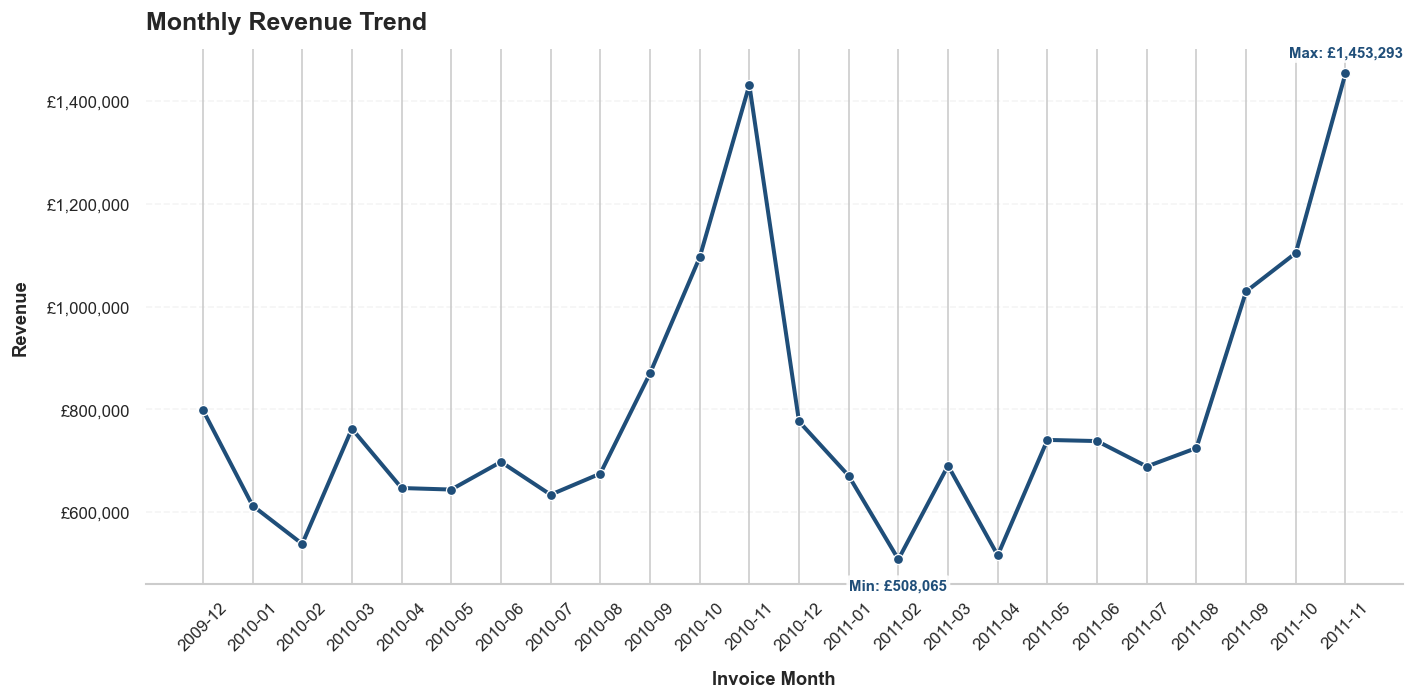

In [11]:
monthly_revenue = (
    df_sales.loc[df_sales['invoice_month'] <= last_complete_month]
            .groupby('invoice_month', as_index=False)
            .agg(revenue=('revenue', 'sum'))
            .sort_values('invoice_month')
            .assign(invoice_month=lambda d: d['invoice_month'].astype(str))
)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_revenue, x='invoice_month', y='revenue', marker='o', linewidth=2.4, color=PRIMARY_COLOR)
style_axes(ax=ax, title='Monthly Revenue Trend', xlabel='Invoice Month', ylabel='Revenue', value_format='currency', value_axis='y')
annotate_line_extremes(ax, monthly_revenue, 'invoice_month', 'revenue', value_format='currency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 6.2 Daily Revenue in the Most Recent Complete Month

This chart shows how revenue changed day by day in the most recent complete month in the dataset. It helps identify short-term spikes, weak days, and within-month sales patterns.

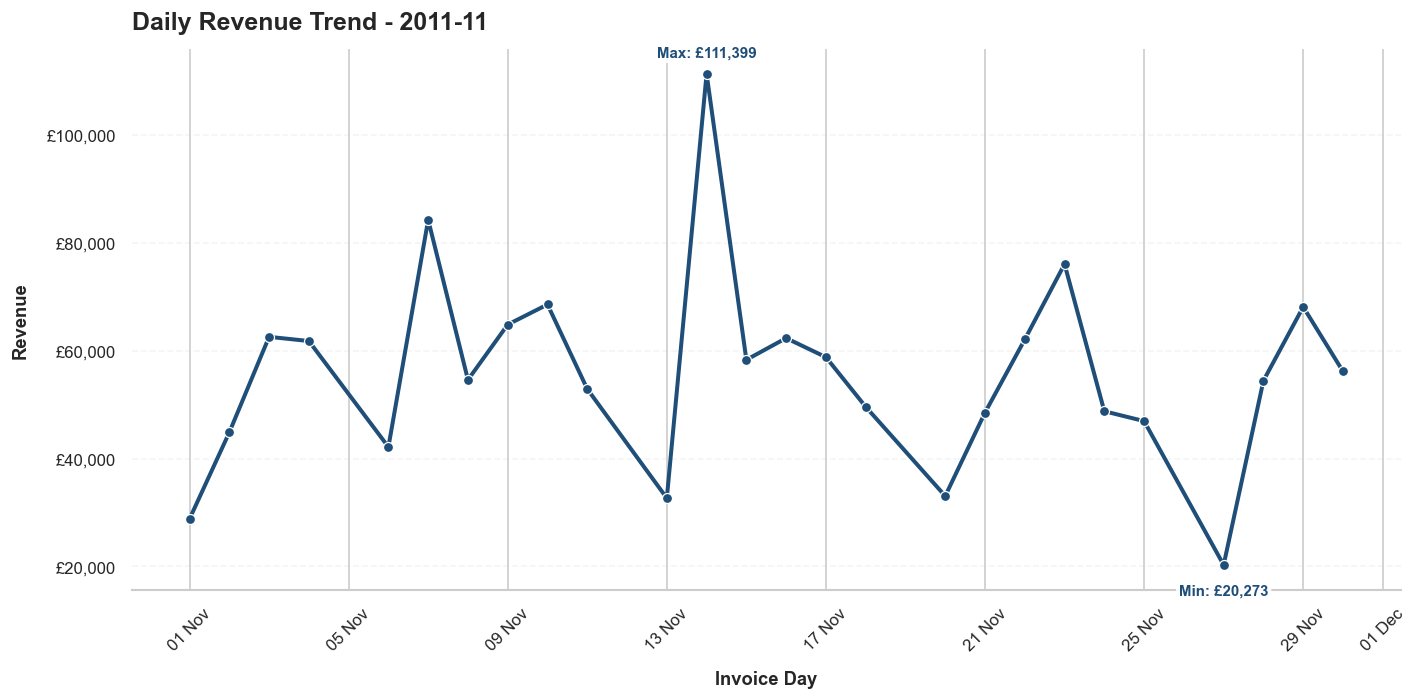

In [12]:
daily_revenue_last_month = (
    df_sales.loc[df_sales['invoice_month'] == last_complete_month]
            .assign(invoice_day=lambda d: pd.to_datetime(d['invoice_date']).dt.normalize())
            .groupby('invoice_day', as_index=False)
            .agg(revenue=('revenue', 'sum'))
            .sort_values('invoice_day')
)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=daily_revenue_last_month, x='invoice_day', y='revenue', marker='o', linewidth=2.4, color=PRIMARY_COLOR)
style_axes(ax=ax, title=f'Daily Revenue Trend - {last_complete_month}', xlabel='Invoice Day', ylabel='Revenue', value_format='currency', value_axis='y')
annotate_line_extremes(ax, daily_revenue_last_month, 'invoice_day', 'revenue', value_format='currency')
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 6.3 Monthly Number of Orders

The number of orders reflects monthly sales activity and shows whether performance changes are driven by transaction volume rather than only by order size.

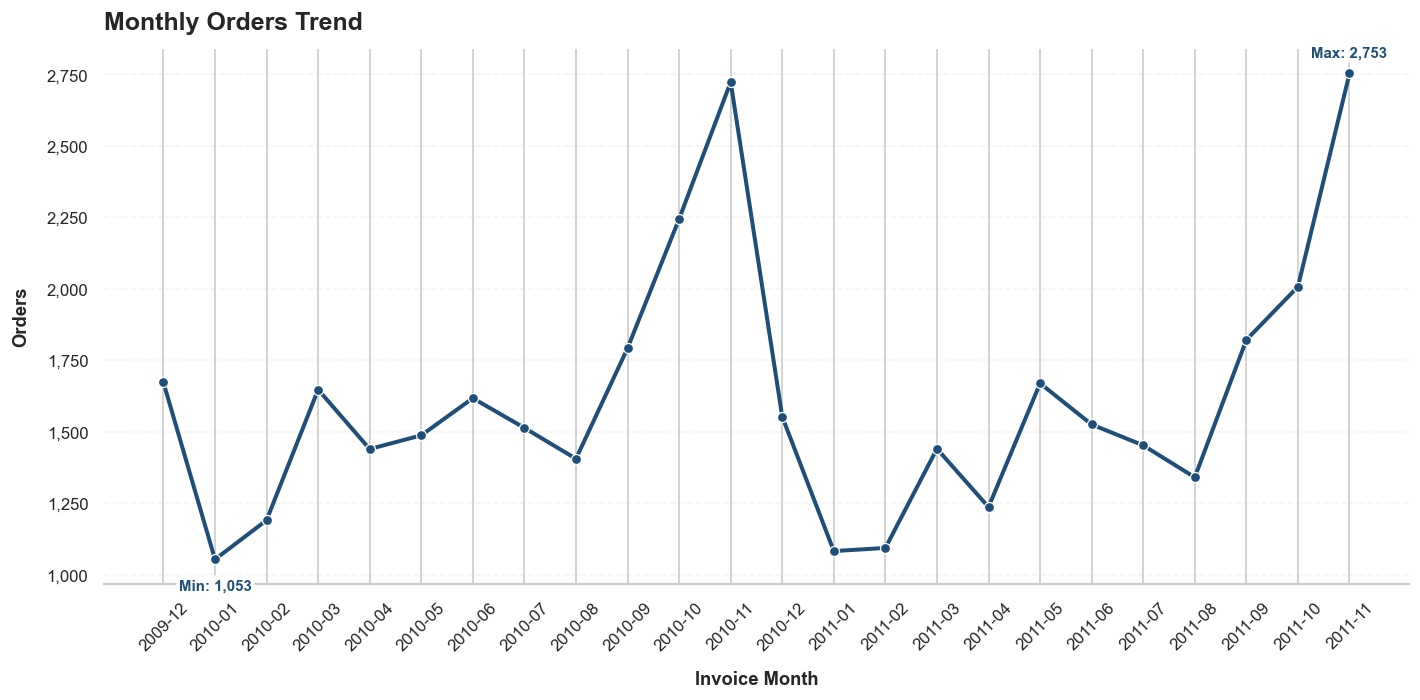

In [13]:
monthly_orders = (
    df_sales.loc[df_sales['invoice_month'] <= last_complete_month]
            .groupby('invoice_month', as_index=False)
            .agg(orders=('invoice', 'nunique'))
            .sort_values('invoice_month')
            .assign(invoice_month=lambda d: d['invoice_month'].astype(str))
)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_orders, x='invoice_month', y='orders', marker='o', linewidth=2.4, color=PRIMARY_COLOR)
style_axes(ax=ax, title='Monthly Orders Trend', xlabel='Invoice Month', ylabel='Orders', value_format='number', value_axis='y')
annotate_line_extremes(ax, monthly_orders, 'invoice_month', 'orders', value_format='number')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 6.4 Monthly Average Order Value

Average order value measures how much revenue is generated per order on average and helps evaluate the quality and size of monthly transactions.

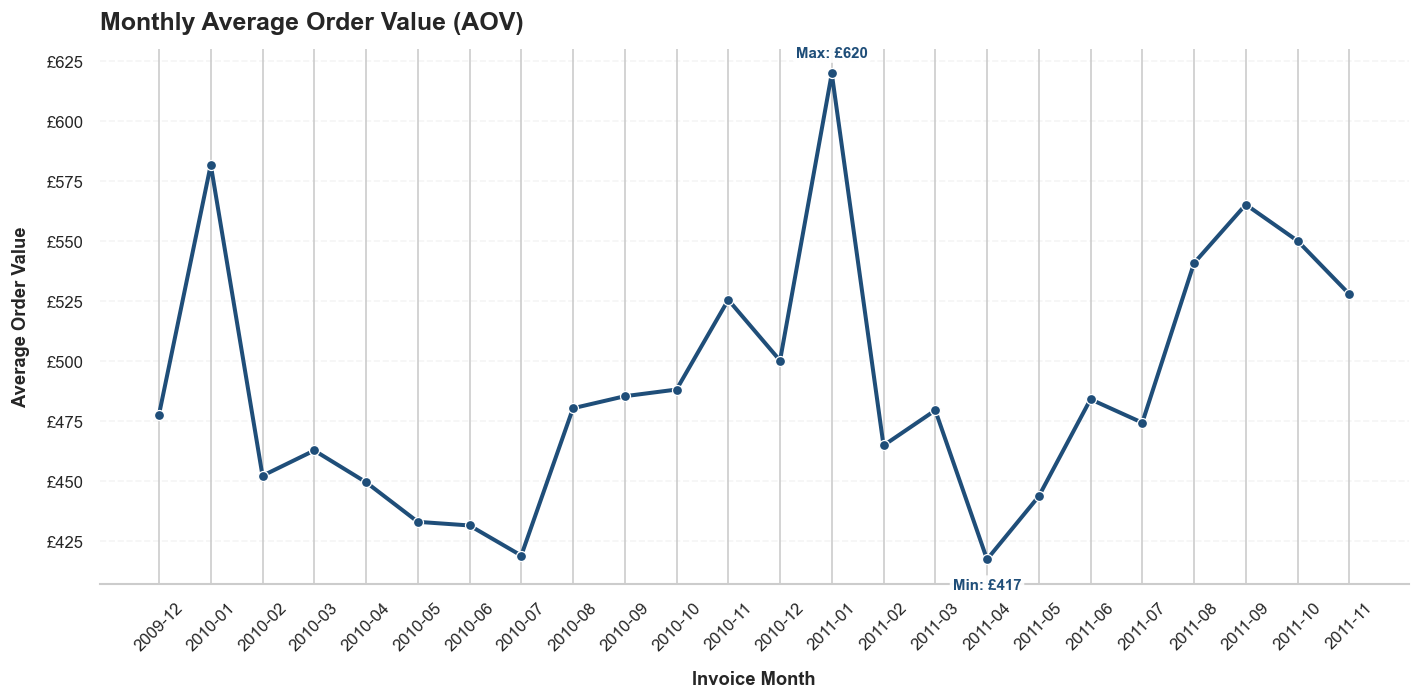

In [14]:
monthly_aov = (
    df_sales.loc[df_sales['invoice_month'] <= last_complete_month]
            .groupby('invoice_month', as_index=False)
            .agg(revenue=('revenue', 'sum'), orders=('invoice', 'nunique'))
            .assign(AOV=lambda d: d['revenue'] / d['orders'])
            .sort_values('invoice_month')
            .assign(invoice_month=lambda d: d['invoice_month'].astype(str))
)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_aov, x='invoice_month', y='AOV', marker='o', linewidth=2.4, color=PRIMARY_COLOR)
style_axes(ax=ax, title='Monthly Average Order Value (AOV)', xlabel='Invoice Month', ylabel='Average Order Value', value_format='currency', value_axis='y')
annotate_line_extremes(ax, monthly_aov, 'invoice_month', 'AOV', value_format='currency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 6.5 Monthly Unique Customers

Monthly unique customers show how many identified customers placed orders in each month and help track customer activity over time.

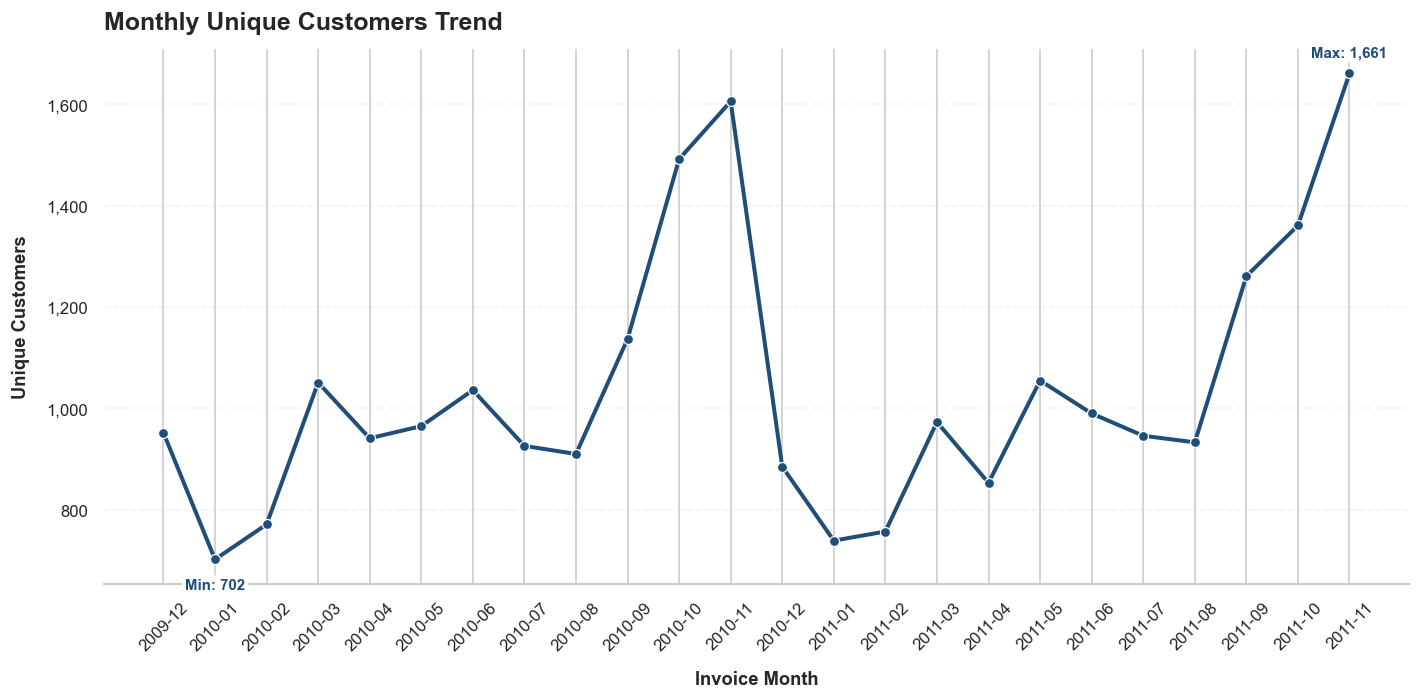

In [15]:
monthly_customers = (
    df_sales.loc[df_sales['invoice_month'] <= last_complete_month]
            .groupby('invoice_month', as_index=False)
            .agg(customers=('customer_id', 'nunique'))
            .sort_values('invoice_month')
            .assign(invoice_month=lambda d: d['invoice_month'].astype(str))
)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=monthly_customers, x='invoice_month', y='customers', marker='o', linewidth=2.4, color=PRIMARY_COLOR)
style_axes(ax=ax, title='Monthly Unique Customers Trend', xlabel='Invoice Month', ylabel='Unique Customers', value_format='number', value_axis='y')
annotate_line_extremes(ax, monthly_customers, 'invoice_month', 'customers', value_format='number')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 7. Product Performance Analysis

### 7.1 Top Products by Revenue


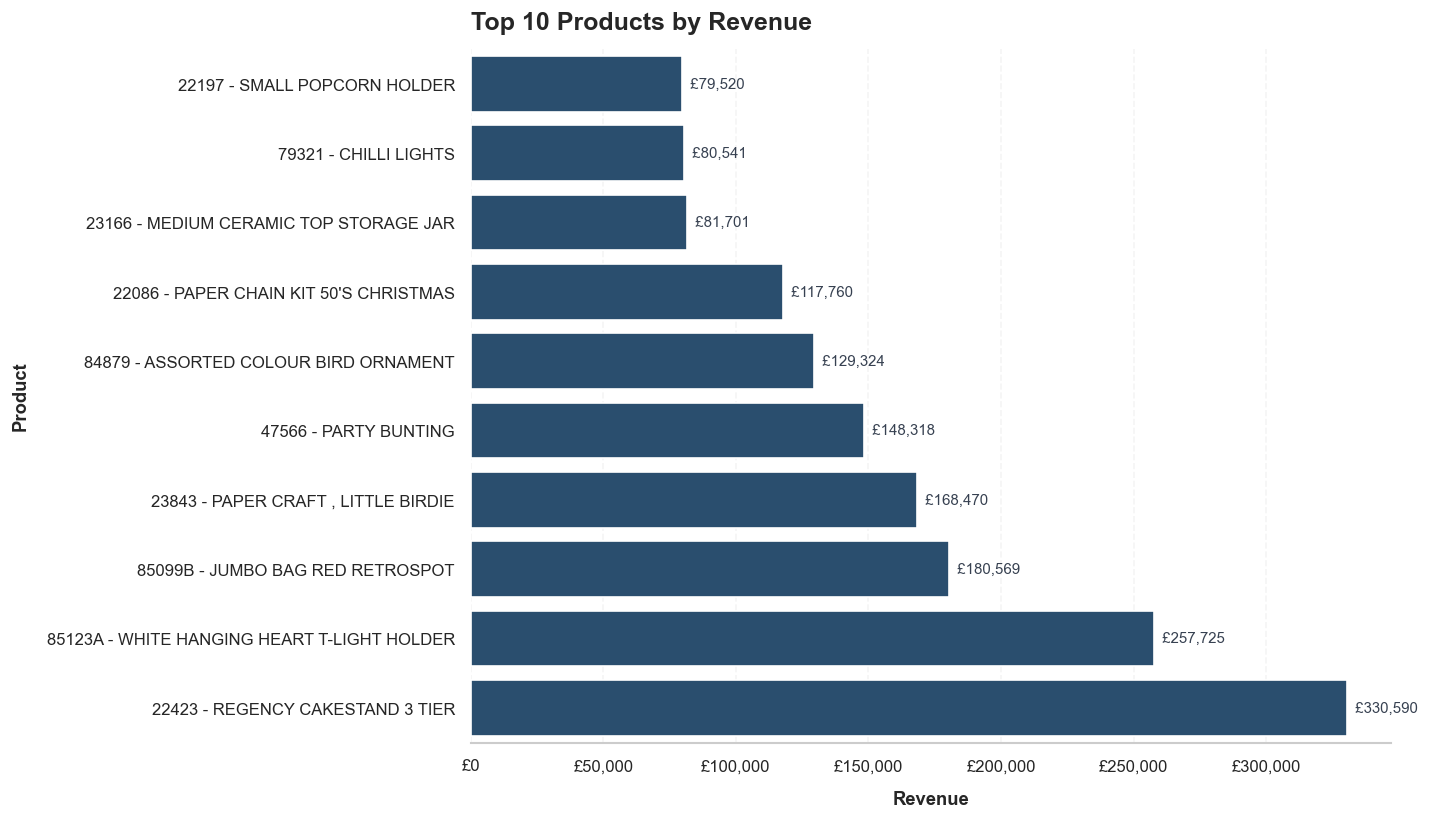

In [16]:
product_labels = (
    df_sales.loc[df_sales['stock_code'].notna() & df_sales['description'].notna(), ['stock_code', 'description']]
            .assign(
                stock_code=lambda d: d['stock_code'].astype(str).str.strip(),
                description=lambda d: d['description'].astype(str).str.strip()
            )
            .groupby(['stock_code', 'description'], as_index=False)
            .size()
            .sort_values(['stock_code', 'size', 'description'], ascending=[True, False, True])
            .drop_duplicates(subset='stock_code')
            .rename(columns={'description': 'product_description'})
            .drop(columns='size')
)

top_products_revenue = (
    df_sales.assign(stock_code=lambda d: d['stock_code'].astype(str).str.strip())
            .groupby('stock_code', as_index=False)
            .agg(revenue=('revenue', 'sum'))
            .merge(product_labels, on='stock_code', how='left')
            .assign(product_label=lambda d: d['stock_code'] + ' - ' + d['product_description'].fillna('Unknown description'))
            .sort_values('revenue', ascending=False)
            .head(10)
            .sort_values('revenue', ascending=True)
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_products_revenue, x='revenue', y='product_label', color=PRIMARY_COLOR)
style_axes(ax=ax, title='Top 10 Products by Revenue', xlabel='Revenue', ylabel='Product', value_format='currency', value_axis='x')
add_bar_labels(ax, value_format='currency')
plt.tight_layout()
plt.show()

### 7.2 Top Products by Units Sold


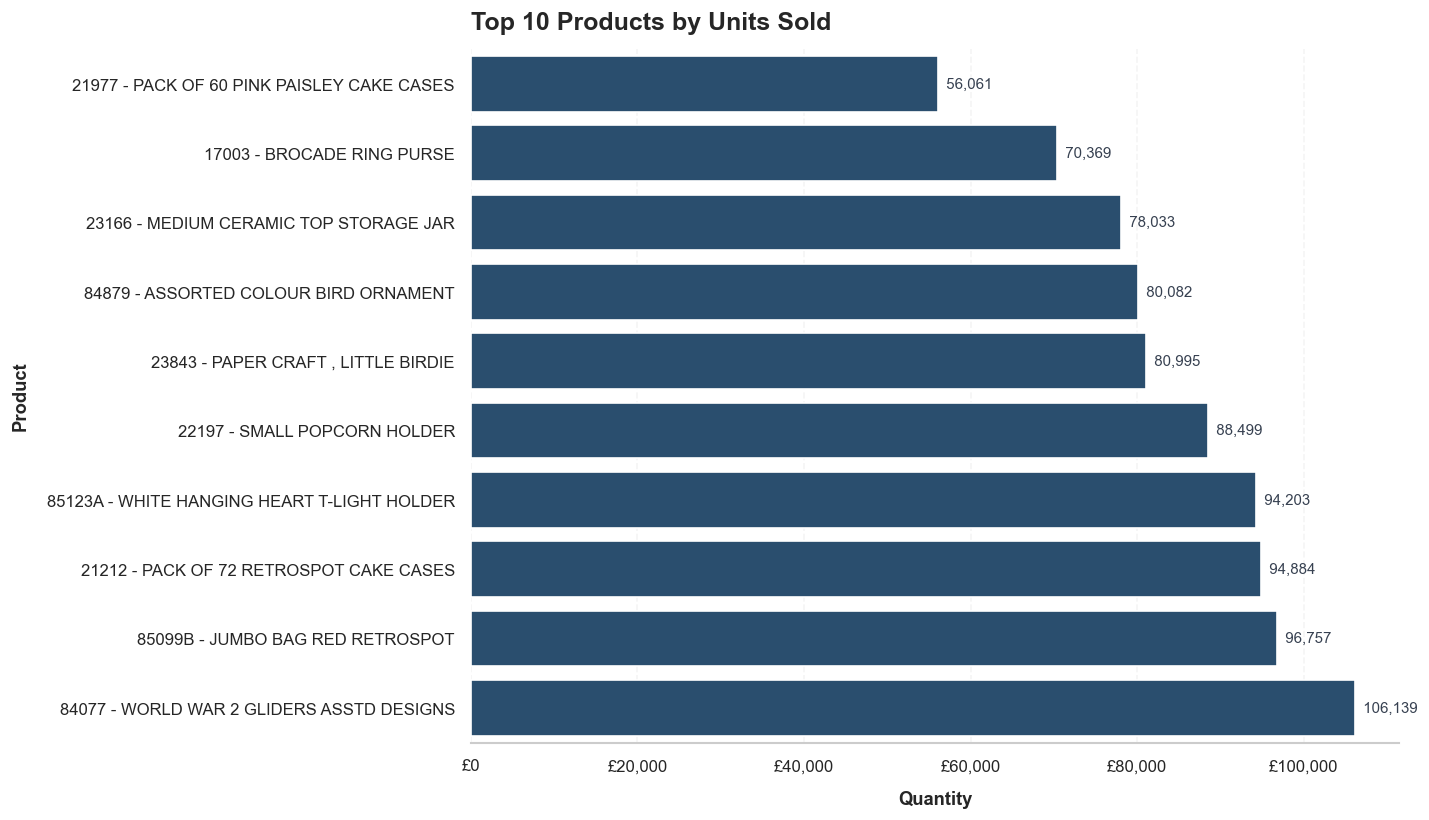

In [17]:
top_products_quantity = (
    df_sales.assign(stock_code=lambda d: d['stock_code'].astype(str).str.strip())
            .groupby('stock_code', as_index=False)
            .agg(quantity=('quantity', 'sum'))
            .merge(product_labels, on='stock_code', how='left')
            .assign(product_label=lambda d: d['stock_code'] + ' - ' + d['product_description'].fillna('Unknown description'))
            .sort_values('quantity', ascending=False)
            .head(10)
            .sort_values('quantity', ascending=True)
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_products_quantity, x='quantity', y='product_label', color=PRIMARY_COLOR)
style_axes(ax=ax, title='Top 10 Products by Units Sold', xlabel='Quantity', ylabel='Product', value_format='currency', value_axis='x')
add_bar_labels(ax, value_format='number')
plt.tight_layout()
plt.show()

# 8. ABC Analysis

### 8.1 ABC Analysis by Product

This analysis ranks products by revenue contribution and classifies them into A, B, and C groups based on cumulative revenue share. It helps identify which products drive most of the business and which ones belong to the long tail.

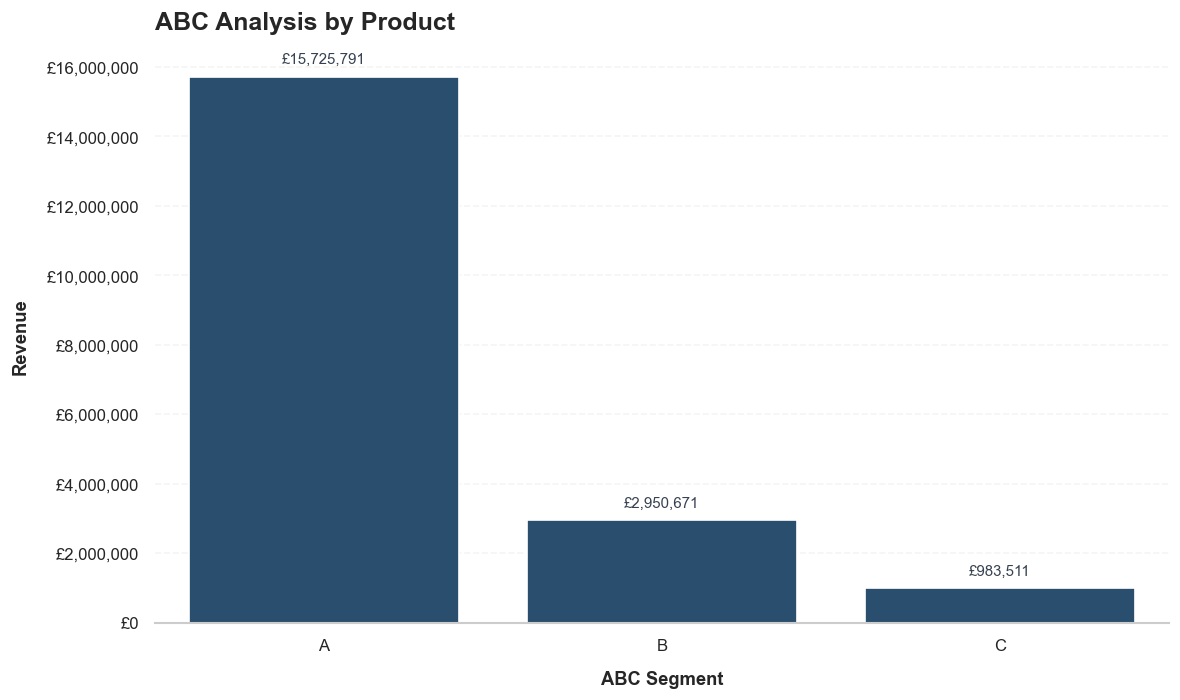

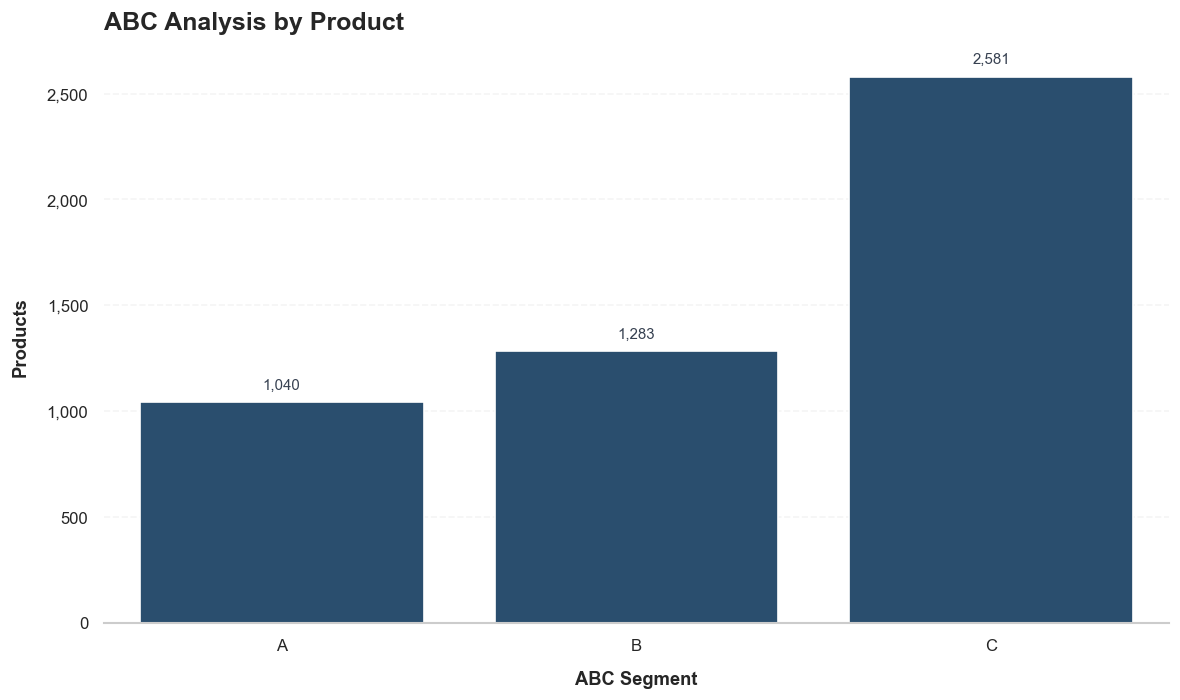

stock_code,revenue,product_description,product_label,revenue_share,cumulative_share,abc_segment
22423,330590.320000,REGENCY CAKESTAND 3 TIER,22423 - REGENCY CAKESTAND 3 TIER,0.016815,0.016815,A
85123A,257724.710000,WHITE HANGING HEART T-LIGHT HOLDER,85123A - WHITE HANGING HEART T-LIGHT HOLDER,0.013109,0.029925,A
85099B,180569.340000,JUMBO BAG RED RETROSPOT,85099B - JUMBO BAG RED RETROSPOT,0.009185,0.039109,A
23843,168469.600000,"PAPER CRAFT , LITTLE BIRDIE","23843 - PAPER CRAFT , LITTLE BIRDIE",0.008569,0.047678,A
47566,148318.280000,PARTY BUNTING,47566 - PARTY BUNTING,0.007544,0.055222,A
84879,129324.490000,ASSORTED COLOUR BIRD ORNAMENT,84879 - ASSORTED COLOUR BIRD ORNAMENT,0.006578,0.061801,A
22086,117760.290000,PAPER CHAIN KIT 50'S CHRISTMAS,22086 - PAPER CHAIN KIT 50'S CHRISTMAS,0.005990,0.067790,A
23166,81700.920000,MEDIUM CERAMIC TOP STORAGE JAR,23166 - MEDIUM CERAMIC TOP STORAGE JAR,0.004156,0.071946,A
79321,80540.880000,CHILLI LIGHTS,79321 - CHILLI LIGHTS,0.004097,0.076043,A
22197,79520.200000,SMALL POPCORN HOLDER,22197 - SMALL POPCORN HOLDER,0.004045,0.080088,A


In [18]:
abc_products = (
    df_sales.assign(stock_code=lambda d: d['stock_code'].astype(str).str.strip())
            .groupby('stock_code', as_index=False)
            .agg(revenue=('revenue', 'sum'))
            .merge(product_labels, on='stock_code', how='left')
            .assign(product_label=lambda d: d['stock_code'] + ' - ' + d['product_description'].fillna('Unknown description'))
            .sort_values('revenue', ascending=False)
)

abc_products['revenue_share'] = abc_products['revenue'] / abc_products['revenue'].sum()
abc_products['cumulative_share'] = abc_products['revenue_share'].cumsum()
abc_products['abc_segment'] = np.select(
    [
        abc_products['cumulative_share'] <= 0.80,
        abc_products['cumulative_share'] <= 0.95
    ],
    ['A', 'B'],
    default='C'
)

abc_product_summary = (
    abc_products.groupby('abc_segment', as_index=False)
                .agg(products=('stock_code', 'nunique'), revenue=('revenue', 'sum'))
                .assign(revenue_share=lambda d: d['revenue'] / d['revenue'].sum())
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=abc_product_summary, x='abc_segment', y='revenue', color=PRIMARY_COLOR)
style_axes(ax=ax, title='ABC Analysis by Product', xlabel='ABC Segment', ylabel='Revenue', value_format='currency', value_axis='y')
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'£{height:,.0f}', (patch.get_x() + patch.get_width() / 2, height), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9, color='#374151')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=abc_product_summary, x='abc_segment', y='products', color=PRIMARY_COLOR)
style_axes(ax=ax, title='ABC Analysis by Product', xlabel='ABC Segment', ylabel='Products', value_format='number', value_axis='y')
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{height:,.0f}', (patch.get_x() + patch.get_width() / 2, height), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9, color='#374151')
plt.tight_layout()
plt.show()

abc_products.head(10).style.hide(axis='index')

### 8.2 ABC Analysis by Customer

Customer-level ABC analysis is calculated on `df_customers`, not on `df_sales`, because customer segmentation only makes sense for rows with a known `customer_id`. Transactions without identified customers can be included in sales KPIs, but they cannot be assigned to a specific customer segment.

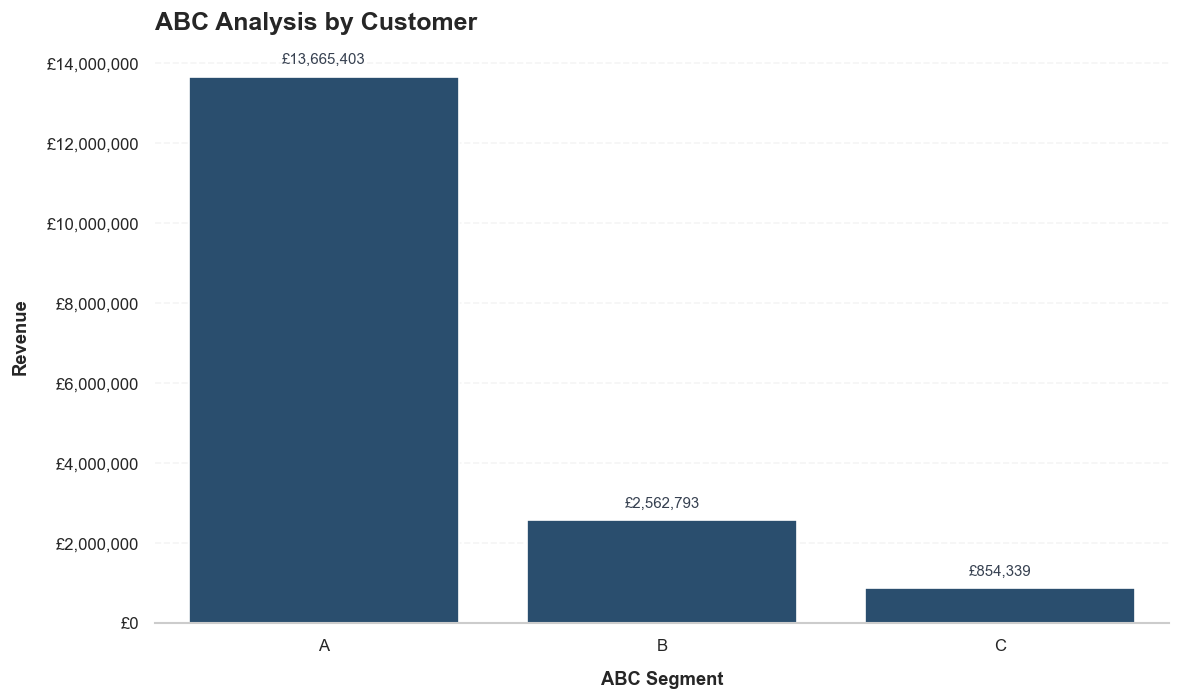

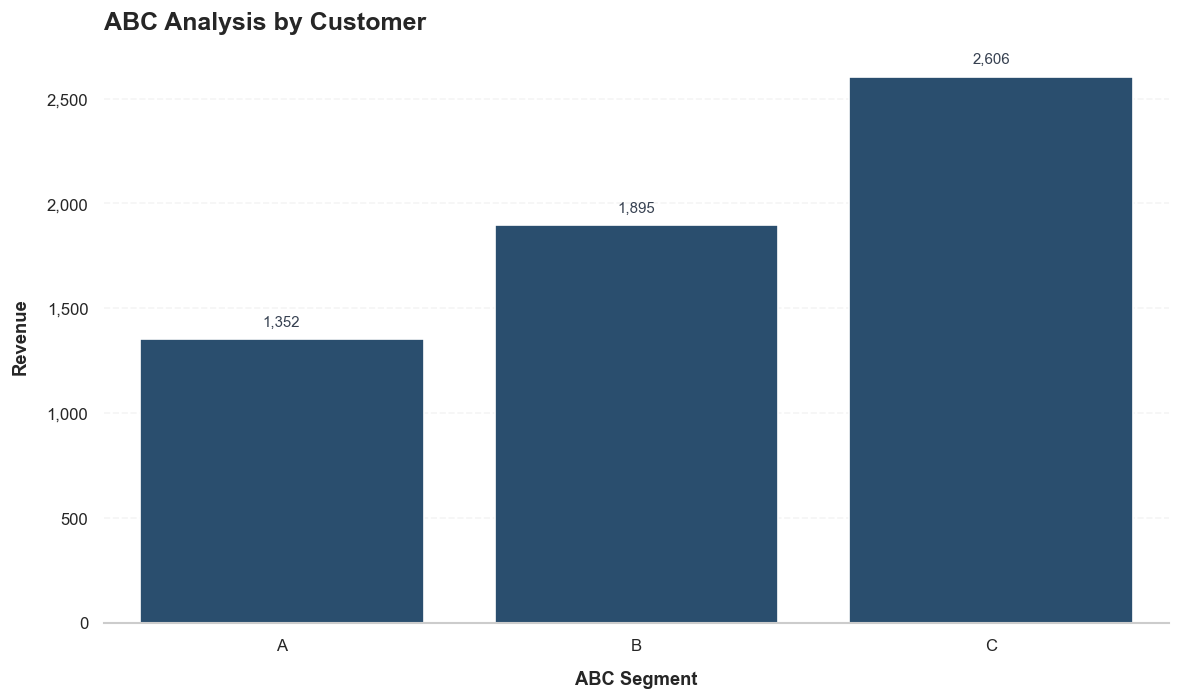

customer_id,revenue,revenue_share,cumulative_share,abc_segment
18102,580987.040000,0.034011,0.034011,A
14646,526751.520000,0.030836,0.064846,A
14156,304719.880000,0.017838,0.082684,A
14911,279492.790000,0.016361,0.099046,A
17450,244784.250000,0.014330,0.113375,A
13694,195640.690000,0.011453,0.124828,A
17511,172132.870000,0.010077,0.134904,A
16446,168472.500000,0.009862,0.144767,A
16684,147142.770000,0.008614,0.153380,A
12415,144033.370000,0.008432,0.161812,A


In [19]:
abc_customers = (
    df_customers.groupby('customer_id', as_index=False)
                .agg(revenue=('revenue', 'sum'))
                .sort_values('revenue', ascending=False)
)

abc_customers['revenue_share'] = abc_customers['revenue'] / abc_customers['revenue'].sum()
abc_customers['cumulative_share'] = abc_customers['revenue_share'].cumsum()
abc_customers['abc_segment'] = np.select(
    [
        abc_customers['cumulative_share'] <= 0.80,
        abc_customers['cumulative_share'] <= 0.95
    ],
    ['A', 'B'],
    default='C'
)

abc_customer_summary = (
    abc_customers.groupby('abc_segment', as_index=False)
                 .agg(customers=('customer_id', 'nunique'), revenue=('revenue', 'sum'))
                 .assign(revenue_share=lambda d: d['revenue'] / d['revenue'].sum())
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=abc_customer_summary, x='abc_segment', y='revenue', color=PRIMARY_COLOR)
style_axes(ax=ax, title='ABC Analysis by Customer', xlabel='ABC Segment', ylabel='Revenue', value_format='currency', value_axis='y')
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'£{height:,.0f}', (patch.get_x() + patch.get_width() / 2, height), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9, color='#374151')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=abc_customer_summary, x='abc_segment', y='customers', color=PRIMARY_COLOR)
style_axes(ax=ax, title='ABC Analysis by Customer', xlabel='ABC Segment', ylabel='Revenue', value_format='number', value_axis='y')
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{height:,.0f}', (patch.get_x() + patch.get_width() / 2, height), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9, color='#374151')
plt.tight_layout()
plt.show()

abc_customers.head(10).style.hide(axis='index')

# 9. Customer Contribution Analysis

### 9.1 Top Customers by Revenue


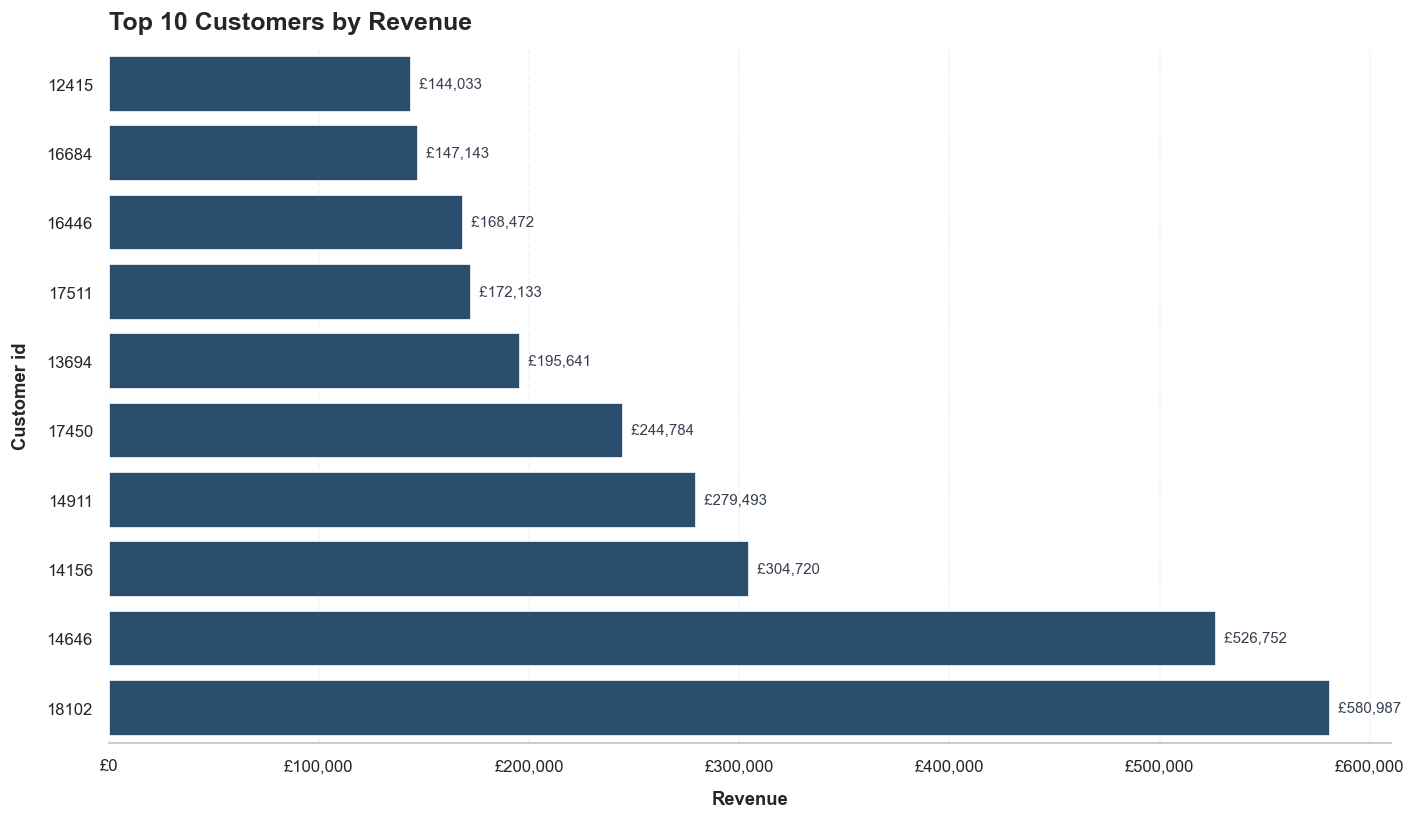

In [20]:
top_customers_revenue = (
    df_customers.assign(customer_id=lambda d: d['customer_id'].astype(str).str.strip())
            .groupby('customer_id', as_index=False)
            .agg(revenue=('revenue', 'sum'))
            .sort_values('revenue', ascending=False)
            .head(10)
            .sort_values('revenue', ascending=True)
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_customers_revenue, x='revenue', y='customer_id', color=PRIMARY_COLOR)
style_axes(ax=ax, title='Top 10 Customers by Revenue', xlabel='Revenue', ylabel='Customer id', value_format='currency', value_axis='x')
add_bar_labels(ax, value_format='currency')
plt.tight_layout()
plt.show()

### 9.2 Revenue Concentration by Customer


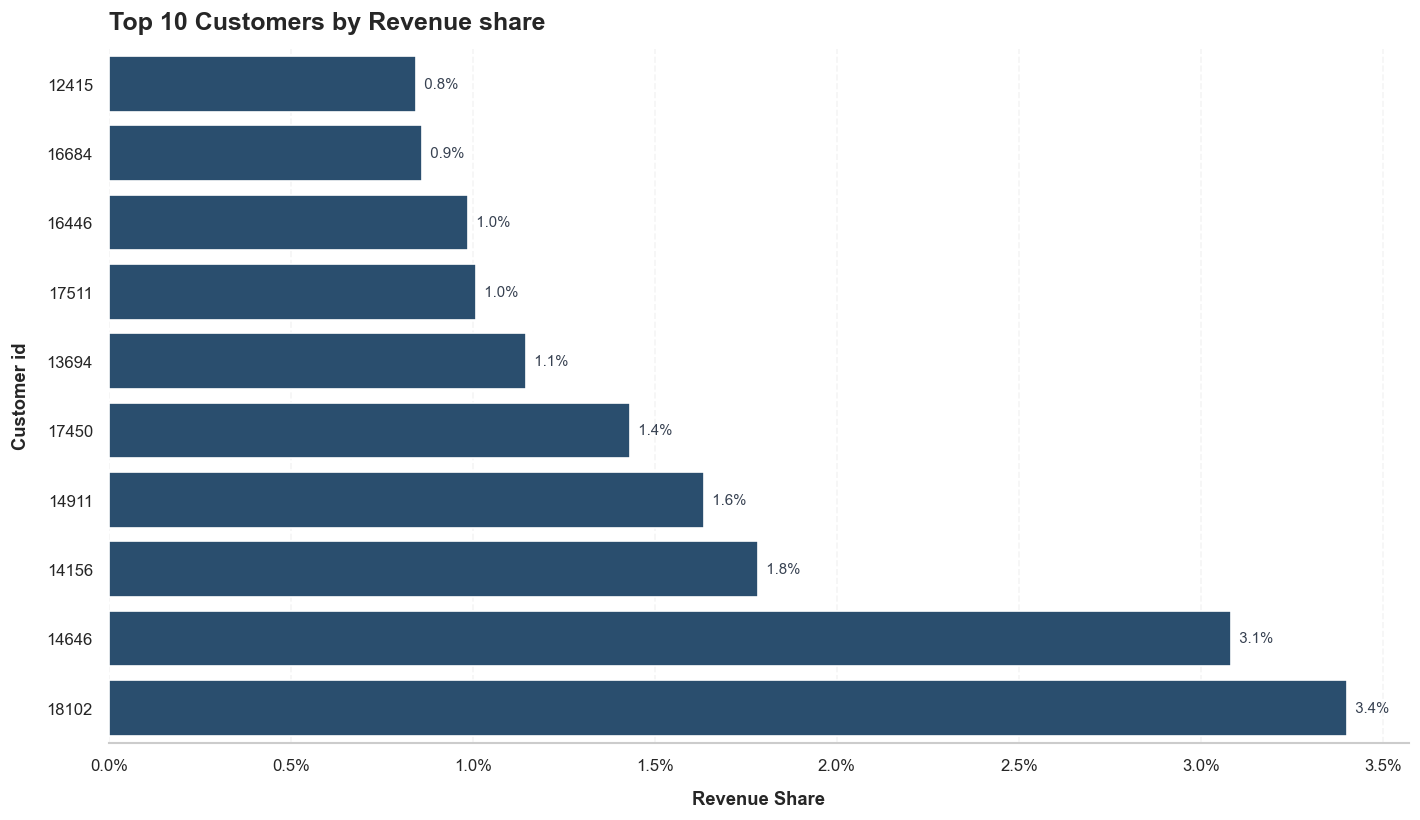

In [21]:
top_customers_revenue_concentration = (
    df_customers.assign(customer_id=lambda d: d['customer_id'].astype(str).str.strip())
            .groupby('customer_id', as_index=False)
            .agg(revenue=('revenue', 'sum'))
)

top_customers_revenue_concentration['revenue_share'] = top_customers_revenue_concentration.revenue / top_customers_revenue_concentration.revenue.sum()
top_customers_revenue_concentration_graph = top_customers_revenue_concentration.sort_values('revenue_share', ascending=False).head(10).sort_values('revenue_share')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_customers_revenue_concentration_graph, x='revenue_share', y='customer_id', color=PRIMARY_COLOR)
style_axes(ax=ax, title='Top 10 Customers by Revenue share', xlabel='Revenue Share', ylabel='Customer id', value_format='percent', value_axis='x')
add_bar_labels(ax, value_format='percent')
plt.tight_layout()
plt.show()


### 9.3 Repeat vs One-Time Customers


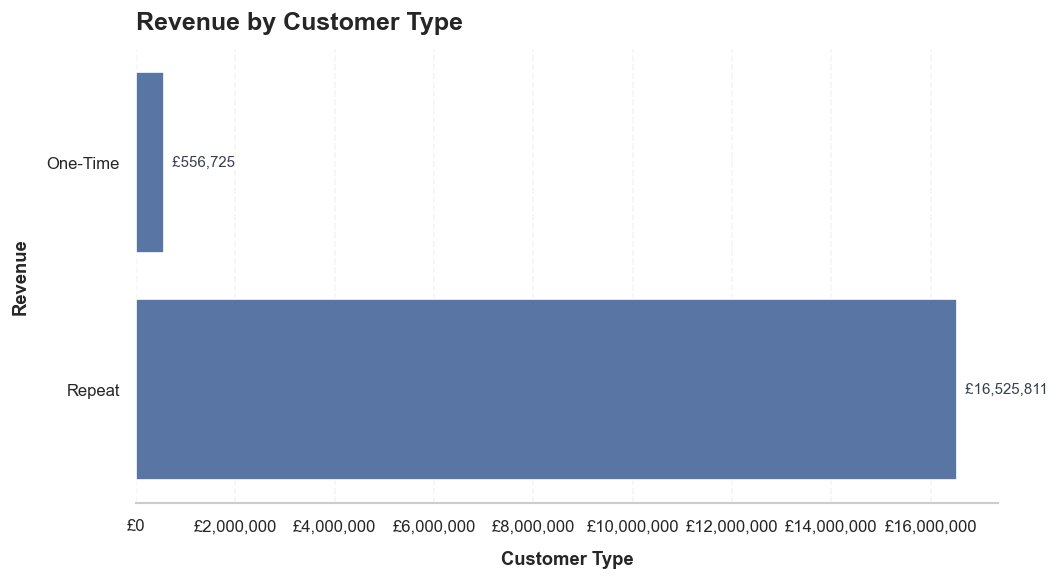

,customer_type,customers,orders,revenue,customer_share_%,order_share_%,revenue_share_%,avg_revenue_per_customer,avg_orders_per_customer
0,One-Time,1619,1619,5.567250e+05,27.66,4.42,3.26,343.87,1.00
1,Repeat,4234,35024,1.652581e+07,72.34,95.58,96.74,3903.12,8.27


In [22]:
# 9.3 Repeat vs One-Time Customers

# Step 1: classify customers by number of unique invoices
customer_order_counts = (
    df_sales.groupby('customer_id')['invoice']
    .nunique()
    .reset_index(name='order_count')
)

customer_order_counts['customer_type'] = np.where(
    customer_order_counts['order_count'] > 1,
    'Repeat',
    'One-Time'
)

# Step 2: attach customer type back to transaction-level data
df_customer_type = df_sales.merge(
    customer_order_counts[['customer_id', 'customer_type']],
    on='customer_id',
    how='left'
)

# Step 3: build summary table
repeat_vs_onetime = (
    df_customer_type.groupby('customer_type')
    .agg(
        customers=('customer_id', 'nunique'),
        orders=('invoice', 'nunique'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

repeat_vs_onetime['customer_share_%'] = (
    repeat_vs_onetime['customers'] / repeat_vs_onetime['customers'].sum() * 100
).round(2)

repeat_vs_onetime['order_share_%'] = (
    repeat_vs_onetime['orders'] / repeat_vs_onetime['orders'].sum() * 100
).round(2)

repeat_vs_onetime['revenue_share_%'] = (
    repeat_vs_onetime['revenue'] / repeat_vs_onetime['revenue'].sum() * 100
).round(2)

repeat_vs_onetime['avg_revenue_per_customer'] = (
    repeat_vs_onetime['revenue'] / repeat_vs_onetime['customers']
).round(2)

repeat_vs_onetime['avg_orders_per_customer'] = (
    repeat_vs_onetime['orders'] / repeat_vs_onetime['customers']
).round(2)

repeat_vs_onetime = repeat_vs_onetime.sort_values('revenue')

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=repeat_vs_onetime,
    y='customer_type',
    x='revenue',
)

style_axes(
    ax,
    title='Revenue by Customer Type',
    xlabel='Customer Type',
    ylabel='Revenue',
    value_format='currency',
    value_axis='x'
)

add_bar_labels(ax, value_format='currency')
plt.tight_layout()
plt.show()

display(repeat_vs_onetime)

# 10. Excel export

In [94]:
def build_line_chart(data, x, y, title, xlabel, ylabel, value_format, is_date_axis=False):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=data, x=x, y=y, marker='o', linewidth=2.4, color=PRIMARY_COLOR, ax=ax)
    style_axes(ax=ax, title=title, xlabel=xlabel, ylabel=ylabel, value_format=value_format, value_axis='y')
    annotate_line_extremes(ax, data, x, y, value_format=value_format)
    if is_date_axis:
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    img = fig_to_xl(fig)
    plt.close(fig)
    return img


def build_bar_chart(data, x, y, title, xlabel, ylabel, value_format, orient='h'):
    fig, ax = plt.subplots(figsize=(12, 7) if orient == 'h' else (10, 6))
    sns.barplot(data=data, x=x, y=y, color=PRIMARY_COLOR, ax=ax)
    style_axes(
        ax=ax,
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        value_format=value_format,
        value_axis='x' if orient == 'h' else 'y'
    )
    if orient == 'h':
        add_bar_labels(ax, value_format=value_format)
    else:
        for patch in ax.patches:
            height = patch.get_height()
            if value_format == 'currency':
                label = f'£{height:,.0f}'
            elif value_format == 'percent':
                label = f'{height * 100:.1f}%'
            else:
                label = f'{height:,.0f}'
            ax.annotate(label, (patch.get_x() + patch.get_width() / 2, height), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9, color='#374151')
    plt.tight_layout()
    img = fig_to_xl(fig)
    plt.close(fig)
    return img


chart_images = {
    'monthly_revenue': build_line_chart(monthly_revenue, 'invoice_month', 'revenue', 'Monthly Revenue Trend', 'Invoice Month', 'Revenue', 'currency'),
    'monthly_revenue_summary': build_line_chart(monthly_revenue, 'invoice_month', 'revenue', 'Monthly Revenue Trend', 'Invoice Month', 'Revenue', 'currency'),
    'daily_revenue_last_month': build_line_chart(daily_revenue_last_month, 'invoice_day', 'revenue', f'Daily Revenue Trend - {last_complete_month}', 'Invoice Day', 'Revenue', 'currency', is_date_axis=True),
    'monthly_orders': build_line_chart(monthly_orders, 'invoice_month', 'orders', 'Monthly Orders Trend', 'Invoice Month', 'Orders', 'number'),
    'monthly_aov': build_line_chart(monthly_aov, 'invoice_month', 'AOV', 'Monthly Average Order Value (AOV)', 'Invoice Month', 'Average Order Value', 'currency'),
    'monthly_customers': build_line_chart(monthly_customers, 'invoice_month', 'customers', 'Monthly Unique Customers Trend', 'Invoice Month', 'Unique Customers', 'number'),
    'top_products_revenue': build_bar_chart(top_products_revenue, 'revenue', 'product_label', 'Top 10 Products by Revenue', 'Revenue', 'Product', 'currency'),
    'top_products_quantity': build_bar_chart(top_products_quantity, 'quantity', 'product_label', 'Top 10 Products by Units Sold', 'Quantity', 'Product', 'number'),
    'abc_products_revenue': build_bar_chart(abc_product_summary, 'abc_segment', 'revenue', 'ABC Analysis by Product', 'ABC Segment', 'Revenue', 'currency', orient='v'),
    'abc_products_count': build_bar_chart(abc_product_summary, 'abc_segment', 'products', 'ABC Analysis by Product', 'ABC Segment', 'Products', 'number', orient='v'),
    'abc_customers_revenue': build_bar_chart(abc_customer_summary, 'abc_segment', 'revenue', 'ABC Analysis by Customer', 'ABC Segment', 'Revenue', 'currency', orient='v'),
    'abc_customers_count': build_bar_chart(abc_customer_summary, 'abc_segment', 'customers', 'ABC Analysis by Customer', 'ABC Segment', 'Customers', 'number', orient='v'),
    'top_customers_revenue': build_bar_chart(top_customers_revenue, 'revenue', 'customer_id', 'Top 10 Customers by Revenue', 'Revenue', 'Customer id', 'currency'),
    'customer_revenue_share': build_bar_chart(top_customers_revenue_concentration_graph, 'revenue_share', 'customer_id', 'Top 10 Customers by Revenue share', 'Revenue Share', 'Customer id', 'percent'),
    'repeat_vs_onetime': build_bar_chart(repeat_vs_onetime, 'revenue', 'customer_type', 'Revenue by Customer Type', 'Revenue', 'Customer Type', 'currency'),
}


In [95]:
output_path = Path("output/monthly_sales_report.xlsx")
output_path.parent.mkdir(exist_ok=True)

# Prepare export tables. Monthly tables use only complete reporting months.
monthly_export = (
    df_sales.loc[df_sales['invoice_month'] <= last_complete_month]
            .groupby('invoice_month', as_index=False)
            .agg(revenue=('revenue', 'sum'), orders=('invoice', 'nunique'), customers=('customer_id', 'nunique'))
            .assign(aov=lambda d: (d['revenue'] / d['orders']).round(2), invoice_month=lambda d: d['invoice_month'].astype(str))
            .sort_values('invoice_month')
            .rename(columns={'invoice_month': 'Month', 'revenue': 'Revenue (£)', 'orders': 'Orders', 'customers': 'Unique Customers', 'aov': 'AOV (£)'})
)

daily_revenue_export = daily_revenue_last_month.assign(invoice_day=lambda d: d['invoice_day'].dt.strftime('%Y-%m-%d')).rename(columns={'invoice_day': 'Day', 'revenue': 'Revenue (£)'})

top_products_revenue_export = top_products_revenue.sort_values('revenue', ascending=False).rename(columns={'product_label': 'Product', 'revenue': 'Revenue (£)'})[['Product', 'Revenue (£)']]
top_products_quantity_export = top_products_quantity.sort_values('quantity', ascending=False).rename(columns={'product_label': 'Product', 'quantity': 'Units Sold'})[['Product', 'Units Sold']]

abc_products_export = (
    abc_products[['abc_segment', 'stock_code', 'product_label', 'revenue', 'revenue_share', 'cumulative_share']]
    .rename(columns={'abc_segment': 'ABC Segment', 'stock_code': 'Stock Code', 'product_label': 'Product', 'revenue': 'Revenue (£)', 'revenue_share': 'Revenue Share', 'cumulative_share': 'Cumulative Share'})
)
abc_product_summary_export = abc_product_summary.rename(columns={'abc_segment': 'ABC Segment', 'products': 'Products', 'revenue': 'Revenue (£)', 'revenue_share': 'Revenue Share'})

abc_customers_export = (
    abc_customers[['abc_segment', 'customer_id', 'revenue', 'revenue_share', 'cumulative_share']]
    .assign(customer_id=lambda d: d['customer_id'].astype(str))
    .rename(columns={'abc_segment': 'ABC Segment', 'customer_id': 'Customer ID', 'revenue': 'Revenue (£)', 'revenue_share': 'Revenue Share', 'cumulative_share': 'Cumulative Share'})
)
abc_customer_summary_export = abc_customer_summary.rename(columns={'abc_segment': 'ABC Segment', 'customers': 'Customers', 'revenue': 'Revenue (£)', 'revenue_share': 'Revenue Share'})

top_customers_revenue_export = top_customers_revenue.sort_values('revenue', ascending=False).rename(columns={'customer_id': 'Customer ID', 'revenue': 'Revenue (£)'})[['Customer ID', 'Revenue (£)']]
top_customers_share_export = top_customers_revenue_concentration_graph.sort_values('revenue_share', ascending=False).rename(columns={'customer_id': 'Customer ID', 'revenue': 'Revenue (£)', 'revenue_share': 'Revenue Share'})[['Customer ID', 'Revenue (£)', 'Revenue Share']]
repeat_vs_onetime_export = repeat_vs_onetime.rename(columns={'customer_type': 'Customer Type', 'customers': 'Customers', 'orders': 'Orders', 'revenue': 'Revenue (£)', 'customer_share_%': 'Customer Share (%)', 'order_share_%': 'Order Share (%)', 'revenue_share_%': 'Revenue Share (%)', 'avg_revenue_per_customer': 'Avg Revenue per Customer (£)', 'avg_orders_per_customer': 'Avg Orders per Customer'})

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    complete_sales = df_sales.loc[df_sales['invoice_month'] <= last_complete_month]
    kpi_table = pd.DataFrame({
        'Metric': ['Reporting Through', 'Total Revenue (£)', 'Total Orders', 'Avg Order Value (£)', 'Unique Customers'],
        'Value': [
            str(last_complete_month),
            round(complete_sales['revenue'].sum(), 2),
            complete_sales['invoice'].nunique(),
            round(complete_sales['revenue'].sum() / complete_sales['invoice'].nunique(), 2),
            complete_sales['customer_id'].nunique()
        ]
    })
    kpi_table.to_excel(writer, sheet_name='management_summary', index=False)

    monthly_export.to_excel(writer, sheet_name='monthly_trends', index=False)
    daily_revenue_export.to_excel(writer, sheet_name='daily_last_month', index=False)
    top_products_revenue_export.to_excel(writer, sheet_name='top_products_revenue', index=False)
    top_products_quantity_export.to_excel(writer, sheet_name='top_products_units', index=False)
    abc_product_summary_export.to_excel(writer, sheet_name='abc_products_summary', index=False)
    abc_products_export.to_excel(writer, sheet_name='abc_products_full', index=False)
    abc_customer_summary_export.to_excel(writer, sheet_name='abc_customers_summary', index=False)
    abc_customers_export.to_excel(writer, sheet_name='abc_customers_full', index=False)
    top_customers_revenue_export.to_excel(writer, sheet_name='top_customers_revenue', index=False)
    top_customers_share_export.to_excel(writer, sheet_name='customer_concentration', index=False)
    repeat_vs_onetime_export.to_excel(writer, sheet_name='repeat_vs_onetime', index=False)

    wb = writer.book
    for name in wb.sheetnames:
        ws = wb[name]
        style_headers(ws)
        autofit(ws)
        ws.sheet_view.showGridLines = False

    # Charts are stacked vertically so wide Excel images do not overlap.
    wb['management_summary'].add_image(chart_images['monthly_revenue_summary'], 'A8')

    monthly_chart_start = len(monthly_export) + 3
    wb['monthly_trends'].add_image(chart_images['monthly_revenue'], f'A{monthly_chart_start}')
    wb['monthly_trends'].add_image(chart_images['monthly_orders'], f'A{monthly_chart_start + 42}')
    wb['monthly_trends'].add_image(chart_images['monthly_aov'], f'A{monthly_chart_start + 84}')
    wb['monthly_trends'].add_image(chart_images['monthly_customers'], f'A{monthly_chart_start + 126}')

    wb['daily_last_month'].add_image(chart_images['daily_revenue_last_month'], f'A{len(daily_revenue_export) + 3}')
    wb['top_products_revenue'].add_image(chart_images['top_products_revenue'], f'A{len(top_products_revenue_export) + 3}')
    wb['top_products_units'].add_image(chart_images['top_products_quantity'], f'A{len(top_products_quantity_export) + 3}')

    abc_product_chart_start = len(abc_product_summary_export) + 3
    wb['abc_products_summary'].add_image(chart_images['abc_products_revenue'], f'A{abc_product_chart_start}')
    wb['abc_products_summary'].add_image(chart_images['abc_products_count'], f'A{abc_product_chart_start + 42}')

    abc_customer_chart_start = len(abc_customer_summary_export) + 3
    wb['abc_customers_summary'].add_image(chart_images['abc_customers_revenue'], f'A{abc_customer_chart_start}')
    wb['abc_customers_summary'].add_image(chart_images['abc_customers_count'], f'A{abc_customer_chart_start + 42}')

    wb['top_customers_revenue'].add_image(chart_images['top_customers_revenue'], f'A{len(top_customers_revenue_export) + 3}')
    wb['customer_concentration'].add_image(chart_images['customer_revenue_share'], f'A{len(top_customers_share_export) + 3}')
    wb['repeat_vs_onetime'].add_image(chart_images['repeat_vs_onetime'], f'A{len(repeat_vs_onetime_export) + 3}')

print(f'Saved -> {output_path}')


Saved -> output/monthly_sales_report.xlsx
